# **Final Aerocapture Trajectory Model**

**IMPORTS**

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

**VEHICLE PARAMETERS**

In [36]:
vehicle_mass = 10000.0                 # kg
vehicle_lift_to_drag = 1.0
vehicle_ballistic_coefficient = 40.0   # kg/m²
vehicle_nose_radius = 3.5              # m

**MARSIAN PARAMETERS**

In [37]:
mars_mu = 4.2828e13                    # m³/s²
mars_radius = 3396000.0                # m

**INITIAL CONDITIONS**

In [38]:
initial_velocity = 16000.0             # m/s
initial_altitude = 130000.0            # m
initial_gamma = np.radians(-11)      # rad
initial_downrange = 0.0                # m
initial_theta = 0.0                    # rad

initial_state = [
    initial_altitude,
    initial_downrange,
    initial_velocity,
    initial_gamma,
    initial_theta
]

**ATMOSPHERE MODEL FUNCTION**

In [39]:
def mars_atmosphere_density(altitude):
    """
    Calculates the atmospheric density at a given altitude above Mars.

    Parameters
    ----------
    altitude : float
        Altitude above the Martian surface in meters.

    Returns
    -------
    float
        Atmospheric density in kg/m³.
    """

    if altitude >= 130000:
        return 0.0

    elif altitude >= 40000:
        return (
            3.7e-4
            * np.exp(-1.371e-4 * (altitude - 40000))
        )

    elif altitude >= 20000:
        return (
            2.8e-3
            * np.exp(-1.012e-4 * (altitude - 20000))
        )

    elif altitude >= 0:
        return (
            1.417e-2
            * np.exp(-0.8109e-4 * altitude)
        )

    else:
        # Below the surface.
        # Prevents None from ever being returned.
        return 0

**EQUATIONS OF MOTION**

In [40]:
def spacecraft_dynamics(time, state, bank_angle):
    """
    Equations of motion for the aerocapture trajectory.

    Parameters
    ----------
    time : float
        Current simulation time in seconds. Included for compatibility
        with the ODE solver.
    state : array_like
        State vector containing:
        - altitude above the Martian surface (m)
        - downrange distance along the Martian surface (m)
        - velocity (m/s)
        - flight path angle (rad)
        - true anomaly, theta (rad)
    bank_angle : float
        Bank angle of the spacecraft in radians.

    Returns
    -------
    list
        Time derivatives of the state vector:
        [dh/dt, ds/dt, dv/dt, dγ/dt, dθ/dt]
    """

    altitude = state[0]
    downrange = state[1]
    velocity = state[2]
    gamma = state[3]
    theta = state[4]

    density = mars_atmosphere_density(altitude)

    radius = mars_radius + altitude

    gravity = mars_mu / radius**2

    drag_force = (0.5 * density * velocity**2 * vehicle_mass / vehicle_ballistic_coefficient)

    lift_force = drag_force * vehicle_lift_to_drag

    altitude_rate = velocity * np.sin(gamma)

    downrange_rate = (mars_radius / radius) * velocity * np.cos(gamma)

    velocity_rate = (-drag_force / vehicle_mass - gravity * np.sin(gamma))

    gamma_rate = ((lift_force * np.cos(bank_angle)) / (vehicle_mass * velocity) + ((velocity**2 / radius) - gravity) * np.cos(gamma) / velocity)

    theta_rate = (velocity * np.cos(gamma) / radius)

    return [
        altitude_rate,
        downrange_rate,
        velocity_rate,
        gamma_rate,
        theta_rate
    ]

**THERMAL FUNCTIONS**

**Radiative Heat Flux Correlations for Mars**

Below 6km/s Model

In [41]:
def mars_slow(V, rho, Rn):
    """
    Low-speed Mars radiative heating correlation (Eq. 7)

    Parameters
    ----------
    V : Freestream velocity [km/s]
    rho : Freestream density [kg/m^3]
    Rn : Effective nose radius [m]

    Returns
    -------
    q_rad : Radiative heat flux [W/m^2]
    """
    
    L = np.log(rho)

    f = (
        # Constant + first order
        -6.0539
        + 4.6540*V
        - 0.3880*L
        + 0.2274*Rn

        # Second order
        - 0.3080*V**2
        - 0.1430*V*L
        - 0.0914*V*Rn
        - 0.1584*L**2
        - 0.0856*L*Rn
        - 0.0573*Rn**2

        # Third order
        - 0.1212*V**3
        + 0.0935*V**2*L
        + 0.0371*V**2*Rn
        + 5.7929e-3*V*L**2
        - 7.4995e-4*V*Rn**2
        + 3.9562e-4*V*L*Rn
        - 9.3175e-3*L**3
        - 2.8918e-3*L**2*Rn
        + 4.0269e-3*L*Rn**2
        + 4.3082e-3*Rn**3

        # Fourth order
        + 0.0164*V**4
        - 6.6590e-3*V**3*L
        - 2.8111e-3*V**3*Rn
        + 1.0757e-3*V**2*L**2
        + 1.4478e-3*V**2*L*Rn
        + 2.9279e-4*V**2*Rn**2
        - 7.0553e-4*V*L**3
        - 2.0861e-4*V*Rn**3
        - 6.7496e-4*V*L**2*Rn
        - 7.5224e-4*V*L*Rn**2
        - 5.2606e-4*L**4
        - 3.4735e-4*L**3*Rn
        - 1.3343e-4*L**2*Rn**2
        - 8.5005e-5*L*Rn**3
        - 8.5250e-5*Rn**4
    )

    q_rad = np.exp(f)   
    return q_rad


Interpolation of F(V) Values for Earth and Mars Based on Emperical Data for Radiative Heat Flux

In [42]:
# Earth 
v_earth = np.array([9000, 9250, 9500, 9750,
    10000, 10250, 10500, 10750,
    11000, 11500, 12000, 12500,
    13000, 13500, 14000, 14500,
    15000, 15500, 16000])

f_earth = np.array([1.5, 4.3, 9.7, 19.5,
    35, 55, 81, 115,
    151, 238, 359, 495,
    660, 850, 1065, 1313,
    1550, 1780, 2040])

# Mars
v_mars = np.array([6000, 6150, 6300, 6500,
    6700, 6900, 7000, 7200,
    7400, 7600, 7800, 8000,
    8200, 8400, 8600, 8800,
    9000])

f_mars =np.array([0.2, 1.0, 1.95, 3.42,
    5.1, 7.1, 8.1, 10.2,
    12.5, 14.8, 17.1, 19.2,
    21.4, 24.1, 26.0, 28.9,
    32.8])

# Interpolation for f(v) values

f_interp = interp1d(v_earth, f_earth, kind='linear')
f_interp_mars = interp1d(v_mars, f_mars, kind='linear')

Between 6km/s and 9km/s Model

In [43]:
def mars_medium(V, rho, Rn):
    """
        Medium speed Mars radiative heating correlation
    
        Parameters
        ----------
        V : Freestream velocity [km/s]
        rho : Freestream density [kg/m^3]
        Rn : Effective nose radius [m]

        Returns
        -------
        q_rad : Radiative heat flux [W/m^2]
    """

    V_table = np.clip(V*1000, v_mars[0], v_mars[-1]) #Clips the table values to avoid extrapolation
    fmars = f_interp_mars(V_table)
    alpha = 2.35e4
    q_rad = alpha * (Rn ** 0.526) * (rho ** 1.19) * fmars
    return q_rad

Above 9km/s Model

In [44]:
def earth_fast(V, rho, Rn):
     
    """
    Fast-speed Earth radiative heating relation (Equivalent to Mars at that speed)
    
    Parameters
    ----------
    V : Freestream velocity [km/s]
    rho : Atmospheric density [kg/m^3]
    Rn : Effective nose radius [m]

    Returns
    -------
    q_rad : Radiative heat flux [W/cm^2]
    """

    V_table = np.clip(V*1000, v_earth[0], v_earth[-1]) #Clips the table values to avoid extrapolation
    fE = f_interp(V_table)
    alpha = 4.72e4
    q_rad = alpha * (Rn ** 0.47) * (rho ** 1.22) * fE
    return q_rad

**Convective Heat Flux Correlation for Mars**

In [45]:
def convective_heat_flux(V, rho, Rn):
    """
    Convective heat flux correlation (Sutton-Graves)

    Parameters
    ----------
    V : Freestream velocity [km/s]
    rho : Atmospheric density [kg/m^3]
    Rn : Effective nose radius [m]

    Returns
    -------
    q_conv : Convective heat flux [W/cm^2]
    """
    q_conv = 18.3 * np.sqrt(rho / Rn) * (V ** 3)
    return q_conv


**G-LOAD FUNCTION**

In [46]:
def g_load_func(altitude, velocity,):
    """
    G-load calculation based on the current altitude and velocity of the spacecraft.

    Parameters
    ----------
    altitude : Current altitude taken from altitude_trajectory array [km]
    velocity : Current velocity taken from velocity_trajectory array [km/s]

    Returns
    -------
    g_load : G-load experienced by the spacecraft [g's]
    """

    density = mars_atmosphere_density(altitude)
    drag_force = (0.5 * density * velocity**2 * vehicle_mass / vehicle_ballistic_coefficient)
    lift = (drag_force * vehicle_lift_to_drag)
    g_load = np.sqrt(drag_force**2 + lift**2) / (vehicle_mass * 9.80665)
    return g_load

**HISTORY ARRAYS**

In [47]:
trajectory_history = []

trajectory_time_history = []

trajectory_bank_history = []


simulation_time = 0.0

**STEP 1 CONTROL**

Set Initial Controls for step 1

In [48]:
STEP1_TARGET_ALTITUDE = 60000.0          # m
STEP1_ALTITUDE_TOLERANCE = 1000.0        # ±1 km

STEP1_BANK_MIN = 0.0                     # deg
STEP1_BANK_MAX = 180.0                   # deg
STEP1_NUMBER_OF_BANKS = 37

STEP1_MAX_BANK_RATE = np.radians(10.0)   # rad per guidance step

STEP1_GUIDANCE_TIMESTEP = 2.0            # s

STEP1_MAX_ITERATIONS = 500

Detect first crossing of 60 km (defined target altitude) while descending

In [49]:
def step1_altitude_event(time, state, bank_angle):
    """
    Event function that terminates Step 1 when the target altitude is reached.

    Parameters
    ----------
    time : float
        Current simulation time in seconds.
    state : array_like
        Current spacecraft state vector:
        [altitude, downrange, velocity, flight path angle, theta].
    bank_angle : float
        Current bank angle in radians. Included because it is passed to the
        equations of motion, although it is not used by this event function.

    Returns
    -------
    float
        Difference between the current altitude and the Step 1 target altitude.
        The event is triggered when this value crosses zero.
    """

    altitude = state[0]

    return altitude - STEP1_TARGET_ALTITUDE


# Trigger only while descending through the target altitude.
step1_altitude_event.direction = -1

# Stop the integration when the event occurs.
step1_altitude_event.terminal = True

Predict trajectory until first 60 km (defined target altitude) crossing

In [50]:
def step1_predict_to_target(state_initial, bank_angle):
    """
    Propagates the spacecraft trajectory until the Step 1 target altitude
    is reached.

    Parameters
    ----------
    state_initial : array_like
        Initial spacecraft state vector:
        [altitude, downrange, velocity, flight path angle, theta].
    bank_angle : float
        Constant bank angle in radians used during the prediction.

    Returns
    -------
    ndarray or None
        Spacecraft state at the target altitude if the target is reached.
        Returns None if the trajectory never reaches the target altitude.
    """

    prediction_solution = solve_ivp(
        spacecraft_dynamics,
        [0.0, 2000.0],
        state_initial,
        args=(bank_angle,),
        events=step1_altitude_event,
        max_step=2.0,
        rtol=1e-8,
        atol=1e-8
    )

    # Vehicle never reached the target altitude.
    if len(prediction_solution.t_events[0]) == 0:
        return None

    state_at_target = prediction_solution.y_events[0][0]

    return state_at_target

Find bank angle giving smallest |γ| at 60 km (defined target altitude)

In [51]:
def step1_find_best_bank(state_initial):
    """
    Determines the bank angle that best guides the spacecraft to the
    Step 1 target altitude.

    Candidate bank angles are evaluated by predicting the trajectory to the
    target altitude. Of the trajectories that reach the target altitude within
    the specified tolerance, the bank angle that produces a flight path angle
    closest to zero is selected.

    Parameters
    ----------
    state_initial : array_like
        Initial spacecraft state vector:
        [altitude, downrange, velocity, flight path angle, theta].

    Returns
    -------
    float or None
        Selected bank angle in radians. Returns None if no valid bank angle
        satisfies the target altitude condition.
    """

    candidate_banks = np.radians(np.linspace(STEP1_BANK_MIN, STEP1_BANK_MAX, STEP1_NUMBER_OF_BANKS))

    valid_predictions = []

    # Evaluate each candidate bank angle.
    for candidate_bank in candidate_banks:
        predicted_state = step1_predict_to_target(state_initial, candidate_bank)

        # Ignore trajectories that never reach the target altitude.
        if predicted_state is None:
            continue

        predicted_altitude = predicted_state[0]
        predicted_gamma = predicted_state[3]

        # Keep only trajectories that reach the target altitude within the specified tolerance.
        if (STEP1_TARGET_ALTITUDE - STEP1_ALTITUDE_TOLERANCE <= predicted_altitude <= STEP1_TARGET_ALTITUDE + STEP1_ALTITUDE_TOLERANCE):
            valid_predictions.append((candidate_bank, predicted_gamma))

    # No candidate bank angle produced a valid trajectory.
    if len(valid_predictions) == 0:
        print("STEP 1 : No valid bank found")
        return None

    # Select the trajectory with a flight path angle closest to zero at the target altitude.
    best_prediction = min(valid_predictions, key=lambda prediction: abs(prediction[1]))

    print(
        f"STEP 1 | "
        f"Bank = {np.degrees(best_prediction[0]):6.2f} deg | "
        f"Predicted γ = {np.degrees(best_prediction[1]):7.4f} deg"
    )

    return best_prediction[0]

Guidance loop for step 1

In [52]:
# Reset current state for Step 1
step1_state = initial_state.copy()

# Initial bank value
step1_previous_bank = np.radians(180.0)

step1_iteration = 0

while True:

    step1_iteration += 1

    if step1_iteration > STEP1_MAX_ITERATIONS:
        print("STEP 1 FAILED: Maximum iterations exceeded")
        break

    if step1_state[0] < 30000:
        print("STEP 1 FAILED: Vehicle descended below 30 km")
        break

    if step1_state[0] > 130000:
        print("STEP 1 FAILED: Vehicle exited atmosphere")
        break

    altitude_step1 = step1_state[0]

    gamma_step1 = step1_state[3]


    # Target condition check
    if (
        STEP1_TARGET_ALTITUDE - STEP1_ALTITUDE_TOLERANCE <= altitude_step1 <= STEP1_TARGET_ALTITUDE + STEP1_ALTITUDE_TOLERANCE
        and
        abs(np.degrees(gamma_step1)) <= 0.5
    ):

        print("\nSTEP 1 TARGET REACHED")

        break


    # Find optimal bank angle
    step1_bank_command = step1_find_best_bank(step1_state)

    if step1_bank_command is None:

        print("STEP 1 GUIDANCE FAILED")

        break


    # Limit bank roll rate
    # Prevent unrealistic instantaneous rolls
    step1_bank_command = np.clip(
        step1_bank_command,
        step1_previous_bank - STEP1_MAX_BANK_RATE,
        step1_previous_bank + STEP1_MAX_BANK_RATE
    )

    step1_previous_bank = step1_bank_command


    # Propagate spacecraft
    step1_solution = solve_ivp(
        spacecraft_dynamics,
        [0,STEP1_GUIDANCE_TIMESTEP],
        step1_state,
        args=(step1_bank_command,),
        max_step=0.2,
        rtol=1e-6,
        atol=1e-6
    )

    # Store state
    trajectory_history.append(step1_state.copy())

    trajectory_time_history.append(simulation_time)

    trajectory_bank_history.append(np.degrees(step1_bank_command))

    # update spacecraft state
    step1_state = step1_solution.y[:, -1]

    simulation_time += STEP1_GUIDANCE_TIMESTEP

STEP 1 | Bank = 105.00 deg | Predicted γ = -0.3802 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.3814 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.3838 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.3880 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.3948 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4044 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4149 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | Bank = 105.00 deg | Predicted γ = -0.4211 deg
STEP 1 | B

Final state of step 1

In [53]:
print("\n==============================")
print("STEP 1 FINAL STATE")
print("==============================")


print("Altitude:", step1_state[0]/1000, "km")

print("Velocity:", step1_state[2]/1000, "km/s")

print("Gamma:", np.degrees(step1_state[3]), "deg")

print("Downrange:", step1_state[1]/1000, "km")


# Handoff to step 2
step2_initial_state = step1_state.copy()

step2_initial_bank = step1_previous_bank


STEP 1 FINAL STATE
Altitude: 60.10961342515914 km
Velocity: 15.120519938615795 km/s
Gamma: -0.4289013326097982 deg
Downrange: 706.9748464794823 km


**STEP 2 CONTROL**

In [54]:
print("\n========== STARTING GLIDE PHASE ==========")


========== STARTING GLIDE PHASE ==========


Step 2 initial controls

In [55]:
STEP2_TARGET_ALTITUDE = 60000.0       # m
STEP2_PREDICTION_TIME = 20.0          # seconds

STEP2_MIN_ALTITUDE = 50000.0          # m safety limit

STEP2_GUIDANCE_TIMESTEP = 1.0         # seconds

STEP2_BANK_MIN = 0.0                  # degrees
STEP2_BANK_MAX = 180.0                # degrees
STEP2_NUMBER_OF_BANKS = 50

STEP2_MAX_BANK_RATE = np.radians(10.0) 

STEP2_MAX_ITERATIONS = 1000

Predict Future Trajectory for Candidate Bank Angles

In [56]:
def step2_predict_future(state_initial, bank_angle, prediction_time):
    """
    Predicts the future spacecraft state over a specified time interval.

    The spacecraft trajectory is propagated forward using the equations of
    motion. The predicted final altitude and velocity, along with the minimum
    altitude reached during the prediction period, are returned for use in
    trajectory guidance and constraint checking.

    Parameters
    ----------
    state_initial : array_like
        Initial spacecraft state vector:
        [altitude, downrange, velocity, flight path angle, theta].

    bank_angle : float
        Vehicle bank angle in radians used during trajectory propagation.

    prediction_time : float
        Duration of the future trajectory prediction in seconds.

    Returns
    -------
    tuple
        Predicted final altitude (m), final velocity (m/s), and minimum
        altitude reached during the prediction period (m).
    """

    prediction_solution = solve_ivp(
        spacecraft_dynamics,
        [0, prediction_time],
        state_initial,
        args=(bank_angle,),
        max_step=1.0,
        rtol=1e-6,
        atol=1e-6
    )

    future_altitude = (prediction_solution.y[0,-1])

    future_velocity = (prediction_solution.y[2,-1])

    minimum_altitude = (np.min(prediction_solution.y[0]))

    return (
        future_altitude,
        future_velocity,
        minimum_altitude
    )

Step 2 Bank Selection Controller

In [57]:
def step2_find_best_bank(state_initial, current_bank):
    """
    Determines the bank angle that best guides the spacecraft toward the
    Step 2 target altitude.

    Candidate bank angles are evaluated by predicting the future trajectory
    over a specified prediction period. The bank angle that minimizes the
    altitude error relative to the target altitude is selected. Trajectories
    that descend below the minimum allowable altitude are penalized to prevent
    unsafe flight conditions.

    Parameters
    ----------
    state_initial : array_like
        Initial spacecraft state vector:
        [altitude, downrange, velocity, flight path angle, theta].

    current_bank : float
        Current vehicle bank angle in radians. Used as the initial value if
        no candidate bank angle provides a better trajectory prediction.

    Returns
    -------
    float
        Selected bank angle in radians that provides the closest predicted
        altitude to the Step 2 target condition.
    """

    candidate_banks = np.radians(np.linspace(STEP2_BANK_MIN, STEP2_BANK_MAX, STEP2_NUMBER_OF_BANKS))

    # Initialize the best solution as the current bank angle
    # This prevents an undefined command if no improvement is found.
    best_bank = current_bank

    smallest_error = np.inf

    # Predict trajectory for each candidate bank angle
    for candidate_bank in candidate_banks:
        
        (predicted_altitude, predicted_velocity, minimum_altitude) = step2_predict_future(state_initial, candidate_bank, STEP2_PREDICTION_TIME)

        altitude_error = abs(predicted_altitude - STEP2_TARGET_ALTITUDE)

        # Penalize trajectories that dive too low
        if minimum_altitude < STEP2_MIN_ALTITUDE:

            altitude_error += 1e6

        if altitude_error < smallest_error:

            smallest_error = altitude_error

            best_bank = candidate_bank

    print(
        f"STEP 2 | "
        f"Bank = {np.degrees(best_bank):6.2f} deg | "
        f"Predicted altitude error = "
        f"{smallest_error/1000:.3f} km"
    )

    return best_bank

Step 2 guidance loop

In [58]:
# Initialize Step 2 state from Step 1
step2_state = step2_initial_state.copy()

step2_previous_bank = step2_initial_bank

step2_iteration = 0


while step2_state[2] > 3870.0:

    # Count guidance iterations
    step2_iteration += 1

    # Prevent excessive guidance iterations
    if step2_iteration > STEP2_MAX_ITERATIONS:

        print("\nSTEP 2 FAILURE: Maximum iterations exceeded")

        break

    # Prevent vehicle from descending too low
    if step2_state[0] < 30000.0:

        print("\nSTEP 2 FAILURE: Vehicle descended below 30 km")

        break

    # Prevent vehicle from exiting the atmosphere
    if step2_state[0] >= 130000.0:

        print("\nSTEP 2 FAILURE: Vehicle ascended above 130 km")

        break

    # Find best bank command
    step2_bank_command = step2_find_best_bank(step2_state, step2_previous_bank)

    # Limit bank slew rate
    step2_bank_command = np.clip(step2_bank_command, step2_previous_bank - STEP2_MAX_BANK_RATE, step2_previous_bank + STEP2_MAX_BANK_RATE)

    step2_previous_bank = step2_bank_command

    # Print current condition
    print(
        f"STEP 2 | "
        f"Time = {simulation_time:.1f} s | "
        f"Altitude = {step2_state[0]/1000:.3f} km | "
        f"Velocity = {step2_state[2]/1000:.3f} km/s | "
        f"Bank = {np.degrees(step2_bank_command):.2f} deg"
    )

    # Propagate spacecraft
    step2_solution = solve_ivp(
        spacecraft_dynamics,
        [0, STEP2_GUIDANCE_TIMESTEP],
        step2_state,
        args=(step2_bank_command,),
        max_step=0.1,
        rtol=1e-6,
        atol=1e-6
    )

    # Store state
    trajectory_history.append(step2_state.copy())

    trajectory_time_history.append(simulation_time)

    trajectory_bank_history.append(np.degrees(step2_bank_command))

    # Update spacecraft state
    step2_state = step2_solution.y[:,-1]

    # Update global simulation clock
    simulation_time += STEP2_GUIDANCE_TIMESTEP

STEP 2 | Bank = 135.92 deg | Predicted altitude error = 0.099 km
STEP 2 | Time = 46.0 s | Altitude = 60.110 km | Velocity = 15.121 km/s | Bank = 110.00 deg
STEP 2 | Bank = 139.59 deg | Predicted altitude error = 0.284 km
STEP 2 | Time = 47.0 s | Altitude = 60.016 km | Velocity = 15.053 km/s | Bank = 120.00 deg
STEP 2 | Bank = 146.94 deg | Predicted altitude error = 0.283 km
STEP 2 | Time = 48.0 s | Altitude = 59.957 km | Velocity = 14.986 km/s | Bank = 130.00 deg
STEP 2 | Bank = 146.94 deg | Predicted altitude error = 0.137 km
STEP 2 | Time = 49.0 s | Altitude = 59.921 km | Velocity = 14.919 km/s | Bank = 140.00 deg
STEP 2 | Bank = 150.61 deg | Predicted altitude error = 0.179 km
STEP 2 | Time = 50.0 s | Altitude = 59.898 km | Velocity = 14.852 km/s | Bank = 150.00 deg
STEP 2 | Bank = 150.61 deg | Predicted altitude error = 0.162 km
STEP 2 | Time = 51.0 s | Altitude = 59.882 km | Velocity = 14.785 km/s | Bank = 150.61 deg
STEP 2 | Bank = 150.61 deg | Predicted altitude error = 0.154 km

Step 2 final state

In [59]:
print("\n==============================")
print("STEP 2 FINAL STATE")
print("==============================")

print("Altitude:", step2_state[0]/1000, "km")

print("Velocity:", step2_state[2]/1000, "km/s")

print("Gamma:", np.degrees(step2_state[3]), "deg")

print("Downrange:", step2_state[1]/1000, "km")


# Handoff step 3
step3_initial_state = step2_state.copy()
step3_initial_bank = step2_previous_bank


STEP 2 FINAL STATE
Altitude: 60.021401312777215 km
Velocity: 3.868912419512485 km/s
Gamma: 0.0013685433920961154 deg
Downrange: 5213.745360910245 km


**STEP 3 EXIT**

In [60]:
print("\n========== STARTING STEP 3 EXIT TARGETING PHASE ==========")


========== STARTING STEP 3 EXIT TARGETING PHASE ==========


Step 3 intial controls

In [61]:
STEP3_EXIT_ALTITUDE = 130000.0        # m atmosphere boundary

STEP3_TARGET_APOAPSIS = 500000.0      # m desired apoapsis altitude
STEP3_MIN_APOAPSIS = 450000.0         # m
STEP3_MAX_APOAPSIS = 550000.0         # m

STEP3_BANK_MIN = 0.0                  # degrees
STEP3_BANK_MAX = 180.0                # degrees
STEP3_NUMBER_OF_BANKS = 37

STEP3_PREDICTION_TIME_EXIT = 5000.0   # s

STEP3_GUIDANCE_TIMESTEP = 3.0         # s

STEP3_MAX_BANK_RATE = np.radians(10.0)

STEP3_MAX_ITERATIONS = 1000

Detect the first upward crossing of 130 km

In [62]:
def step3_exit_event(time, state, bank_angle):
    """
    Event function used to detect spacecraft exit from the atmosphere.

    The event is triggered when the spacecraft reaches the specified exit
    altitude while ascending. This allows solve_ivp to terminate propagation
    at the desired atmospheric exit condition.

    Parameters
    ----------
    time : float
        Current simulation time in seconds.

    state : array_like
        Current spacecraft state vector:
        [altitude, downrange, velocity, flight path angle, theta].

    bank_angle : float
        Current spacecraft bank angle in radians.

    Returns
    -------
    float
        Difference between current altitude and the target exit altitude.
        The event occurs when this value reaches zero.
    """

    altitude = state[0]

    return altitude - STEP3_EXIT_ALTITUDE

# Only detect crossings where altitude is increasing
step3_exit_event.direction = 1

# Stop integration once the exit altitude is reached
step3_exit_event.terminal = True

Detect apoapsis

In [63]:
def step3_apoapsis_event(time, state, bank_angle):
    """
    Event function used to detect spacecraft apoapsis.

    Apoapsis occurs when the spacecraft stops climbing and begins descending.
    This is detected by finding when the vertical velocity component becomes
    zero:

        altitude_rate = velocity * sin(gamma)

    The event is triggered only during the transition from positive to
    negative altitude rate, ensuring that the spacecraft is at the maximum
    altitude point of the trajectory.

    Parameters
    ----------
    time : float
        Current simulation time in seconds.

    state : array_like
        Current spacecraft state vector:
        [altitude, downrange, velocity, flight path angle, theta].

    bank_angle : float
        Current spacecraft bank angle in radians.

    Returns
    -------
    float
        Vertical velocity component of the spacecraft. The event occurs when
        this value reaches zero during the descending transition.
    """

    velocity = state[2]

    gamma = state[3]

    altitude_rate = velocity * np.sin(gamma)

    return altitude_rate

# Only detect the transition from climbing to descending
step3_apoapsis_event.direction = -1

# Stop integration once apoapsis is reached
step3_apoapsis_event.terminal = True

Predict Atmospheric Exit and Apoapsis for a Candidate Bank Angle

In [64]:
def step3_predict_apoapsis(state_initial, bank_angle):
    """
    Predicts the spacecraft trajectory from atmospheric exit to apoapsis
    and calculates the required circularization delta-V.

    The spacecraft is first propagated until it exits the atmosphere.
    From the exit state, the trajectory is propagated until apoapsis is
    reached, which is detected when the radial velocity changes from
    positive to negative. The required circularization burn is then
    calculated by comparing the current apoapsis velocity to the circular
    orbital velocity at that altitude.

    Parameters
    ----------
    state_initial : array_like
        Initial spacecraft state vector:
        [altitude, downrange, velocity, flight path angle, theta].

    bank_angle : float
        Vehicle bank angle in radians used during trajectory prediction.

    Returns
    -------
    tuple or None
        Returns:
        exit_state : array_like
            Spacecraft state at atmospheric exit.

        apo_altitude : float
            Apoapsis altitude above the Mars surface in meters.

        delta_v : float
            Required circularization burn magnitude in m/s.

        Returns None if the spacecraft does not exit the atmosphere or
        apoapsis is not reached.
    """
    
    # Propagate until atmospheric exit
    exit_prediction = solve_ivp(
        spacecraft_dynamics,
        [0, STEP3_PREDICTION_TIME_EXIT],
        state_initial,
        args=(bank_angle,),
        events=step3_exit_event,
        max_step=5.0,
        rtol=1e-6,
        atol=1e-6
    )

    # Vehicle never exits atmosphere
    if len(exit_prediction.t_events[0]) == 0:
        return None

    exit_state = (exit_prediction.y_events[0][0])

    # Propagate to apoapsis
    apo_prediction = solve_ivp(
        spacecraft_dynamics,
        [0, STEP3_PREDICTION_TIME_EXIT],
        exit_state,
        args=(bank_angle,),
        events=step3_apoapsis_event,
        max_step=5.0,
        rtol=1e-6,
        atol=1e-6
    )

    # Apoapsis not reached
    if len(apo_prediction.t_events[0]) == 0:
        return None

    apo_state = (apo_prediction.y_events[0][0])

    apo_altitude = apo_state[0]

    apo_velocity = apo_state[2]

    # Calculate circularization burn
    apo_radius = (mars_radius + apo_altitude)

    circular_velocity = np.sqrt(mars_mu / apo_radius)

    delta_v = (circular_velocity - apo_velocity)

    return (
        exit_state,
        apo_altitude,
        delta_v
    )

Bank searcher for step 3

In [65]:
def step3_find_best_bank(state_initial):
    """
    Determines the bank angle that best guides the spacecraft to the
    desired post-aerocapture apoapsis.

    Candidate bank angles are evaluated by predicting the spacecraft trajectory
    through atmospheric exit and propagation to apoapsis. Only trajectories
    that naturally exit the atmosphere and require a positive circularization
    burn are considered valid. The bank angle that produces an apoapsis closest
    to the target apoapsis altitude is selected.

    Parameters
    ----------
    state_initial : array_like
        Initial spacecraft state vector:
        [altitude, downrange, velocity, flight path angle, theta].

    Returns
    -------
    float or None
        Selected bank angle in radians. Returns None if no valid trajectory
        reaches apoapsis or satisfies the burn condition.
    """

    candidate_banks = np.radians(np.linspace(STEP3_BANK_MIN, STEP3_BANK_MAX, STEP3_NUMBER_OF_BANKS))

    valid_predictions = []

    # Evaluate each possible bank angle by predicting the resulting trajectory
    for candidate_bank in candidate_banks:

        prediction = step3_predict_apoapsis(state_initial, candidate_bank)

        # Skip trajectories that fail to exit the atmosphere or reach apoapsis
        if prediction is None:

            continue

        (predicted_exit_state, predicted_apoapsis, predicted_delta_v) = prediction

        # Only keep trajectories that require a positive circularization burn
        if predicted_delta_v <= 0:

            continue

        valid_predictions.append((candidate_bank, predicted_apoapsis, predicted_delta_v))

    if len(valid_predictions) == 0:

        print("STEP 3 : No valid exit trajectory")

        return None

    # Choose apoapsis closest to target
    best_prediction = min(valid_predictions, key=lambda prediction: abs(prediction[1] - STEP3_TARGET_APOAPSIS))

    print(
        f"STEP 3 | "
        f"Bank = {np.degrees(best_prediction[0]):6.2f} deg | "
        f"Apoapsis = {best_prediction[1]/1000:.2f} km | "
        f"dV = {best_prediction[2]:.2f} m/s"
    )

    return best_prediction[0]

Step 3 guidance loop

In [66]:
# Initialize from Step 2
step3_state = step3_initial_state.copy()

step3_previous_bank = step3_initial_bank

step3_iteration = 0

while step3_state[0] < STEP3_EXIT_ALTITUDE:

    # Count guidance iterations
    step3_iteration += 1

    # Prevent excessive guidance iterations
    if step3_iteration > STEP3_MAX_ITERATIONS:

        print("\nSTEP 3 FAILURE: Maximum iterations exceeded")

        break


    # Prevent vehicle from falling too deep into atmosphere
    if step3_state[0] < 30000.0:

        print("\nSTEP 3 FAILURE: Vehicle descended below 30 km")

        break

    # Find bank command
    
    step3_bank_command = step3_find_best_bank(step3_state)

    if step3_bank_command is None:

        print("STEP 3 GUIDANCE FAILED")

        break

    # Limit bank rate
    step3_bank_command = np.clip(step3_bank_command, step3_previous_bank - STEP3_MAX_BANK_RATE, step3_previous_bank + STEP3_MAX_BANK_RATE)

    step3_previous_bank = step3_bank_command

    print(
        f"STEP 3 | "
        f"Time = {simulation_time:.1f}s | "
        f"Altitude = {step3_state[0]/1000:.3f} km | "
        f"Velocity = {step3_state[2]/1000:.3f} km/s | "
        f"Bank = {np.degrees(step3_bank_command):.2f} deg"
    )

    # Propagate spacecraft
    step3_solution = solve_ivp(
        spacecraft_dynamics,
        [0, STEP3_GUIDANCE_TIMESTEP],
        step3_state,
        args=(step3_bank_command,),
        max_step=0.5,
        rtol=1e-6,
        atol=1e-6
    )

    # Store state
    trajectory_history.append(step3_state.copy())

    trajectory_time_history.append(simulation_time)

    trajectory_bank_history.append(np.degrees(step3_bank_command))

    step3_state = step3_solution.y[:,-1]

    simulation_time += STEP3_GUIDANCE_TIMESTEP

print("\n==============================")
print("STEP 3 ATMOSPHERIC EXIT STATE")
print("==============================")


print("Altitude:", step3_state[0]/1000, "km")

print("Velocity:", step3_state[2]/1000, "km/s")

print("Gamma:", np.degrees(step3_state[3]), "deg")

STEP 3 | Bank =  45.00 deg | Apoapsis = 513.19 km | dV = 128.18 m/s
STEP 3 | Time = 694.0s | Altitude = 60.021 km | Velocity = 3.869 km/s | Bank = 89.18 deg
STEP 3 | Bank =  40.00 deg | Apoapsis = 510.55 km | dV = 129.55 m/s
STEP 3 | Time = 697.0s | Altitude = 60.025 km | Velocity = 3.856 km/s | Bank = 79.18 deg
STEP 3 | Bank =  35.00 deg | Apoapsis = 510.18 km | dV = 131.06 m/s
STEP 3 | Time = 700.0s | Altitude = 60.040 km | Velocity = 3.842 km/s | Bank = 69.18 deg
STEP 3 | Bank =  30.00 deg | Apoapsis = 511.52 km | dV = 132.61 m/s
STEP 3 | Time = 703.0s | Altitude = 60.071 km | Velocity = 3.829 km/s | Bank = 59.18 deg
STEP 3 | Bank =  30.00 deg | Apoapsis = 496.35 km | dV = 130.36 m/s
STEP 3 | Time = 706.0s | Altitude = 60.124 km | Velocity = 3.816 km/s | Bank = 49.18 deg
STEP 3 | Bank =  25.00 deg | Apoapsis = 504.09 km | dV = 132.61 m/s
STEP 3 | Time = 709.0s | Altitude = 60.206 km | Velocity = 3.804 km/s | Bank = 39.18 deg
STEP 3 | Bank =  25.00 deg | Apoapsis = 499.26 km | dV = 1

Apoapsis propagation and burn

In [67]:
step3_exit_state = step3_state.copy()

apoapsis_solution = solve_ivp(
    spacecraft_dynamics,
    [0, 20000],
    step3_exit_state,
    args=(0.0,),
    events=step3_apoapsis_event,
    max_step=5,
    rtol=1e-8,
    atol=1e-8
)

if len(apoapsis_solution.t_events[0]) == 0:
    print("STEP 3 : Apoapsis not reached")

else:

    print("\n========== APOAPSIS REACHED ==========")

    apoapsis_state = (apoapsis_solution.y_events[0][0])

    apo_altitude = apoapsis_state[0]

    apo_velocity = apoapsis_state[2]

    print("Apoapsis altitude:", apo_altitude/1000, "km")

    print("Velocity before burn:", apo_velocity/1000, "km/s")

    apo_radius = (mars_radius + apo_altitude)

    circular_velocity = np.sqrt(mars_mu / apo_radius)

    circularization_delta_v = (circular_velocity - apo_velocity)

    print("Circular velocity:", circular_velocity/1000, "km/s")

    print("Circularization burn:", circularization_delta_v, "m/s")

    # Apply burn
    post_burn_state = apoapsis_state.copy()

    post_burn_state[2] += circularization_delta_v

    # Continue trajectory after burn
    post_burn_solution = solve_ivp(
        spacecraft_dynamics,
        [0, 10000],
        post_burn_state,
        args=(0.0,),
        max_step=10,
        rtol=1e-8,
        atol=1e-8
    )


========== APOAPSIS REACHED ==========
Apoapsis altitude: 500.00004713953956 km
Velocity before burn: 3.183274159760583 km/s
Circular velocity: 3.315541133612514 km/s
Circularization burn: 132.2669738519312 m/s


**COMBINING TRAJECTORIES**

In [68]:
# Convert stored trajectory history

trajectory_history = np.array(trajectory_history)


altitude_trajectory = trajectory_history[:,0]

downrange_trajectory = trajectory_history[:,1]

velocity_trajectory = trajectory_history[:,2]

gamma_trajectory = trajectory_history[:,3]

theta_trajectory = trajectory_history[:,4]


trajectory_time_history = np.array(trajectory_time_history)


# ADD POST-ATMOSPHERE PHASES

if 'apoapsis_solution' in locals():

    altitude_total = np.concatenate([altitude_trajectory, apoapsis_solution.y[0] + 0])

    downrange_total = np.concatenate([downrange_trajectory, apoapsis_solution.y[1]])

    velocity_total = np.concatenate([velocity_trajectory, apoapsis_solution.y[2]])

    gamma_total = np.concatenate([gamma_trajectory, apoapsis_solution.y[3]])

    theta_total = np.concatenate([theta_trajectory, apoapsis_solution.y[4]])

    time_total = np.concatenate([trajectory_time_history, trajectory_time_history[-1] + apoapsis_solution.t])

else:

    altitude_total = altitude_trajectory

    downrange_total = downrange_trajectory

    velocity_total = velocity_trajectory

    gamma_total = gamma_trajectory

    theta_total = theta_trajectory

    time_total = trajectory_time_history


# Add post burn orbit
if 'post_burn_solution' in locals():

    altitude_total = np.concatenate([altitude_total, post_burn_solution.y[0]])

    downrange_total = np.concatenate([downrange_total, post_burn_solution.y[1]])

    velocity_total = np.concatenate([velocity_total, post_burn_solution.y[2]])

    gamma_total = np.concatenate([gamma_total, post_burn_solution.y[3]])

    theta_total = np.concatenate([theta_total, post_burn_solution.y[4]])

    time_total = np.concatenate([time_total, time_total[-1] + post_burn_solution.t])

**HEAT FLUX CALCULATIONS**

In [69]:
q_c = []
q_r = []

for h, v in zip(altitude_trajectory, velocity_trajectory):

    V_km = v / 1000
    rho = mars_atmosphere_density(h)

    if 0 <= h < 130000:
        q_c.append(convective_heat_flux(V_km, rho, vehicle_nose_radius))

        if V_km <= 6:
            q_r.append(mars_slow(V_km, rho, vehicle_nose_radius))

        elif V_km < 9:
            q_r.append(mars_medium(V_km, rho, vehicle_nose_radius))

        else:
            q_r.append(earth_fast(V_km, rho, vehicle_nose_radius))

    else:
        q_c.append(0)
        q_r.append(0)

q_c = np.array(q_c)
q_r = np.array(q_r)

q_total = q_c + q_r

**G-LOAD CALCULATION**

In [70]:
g_load_history = []
for altitude, velocity in zip(altitude_trajectory, velocity_trajectory):

    g_load = g_load_func(altitude, velocity)

    g_load_history.append(g_load)

**PLOTS**

**Altitude vs Downrange**

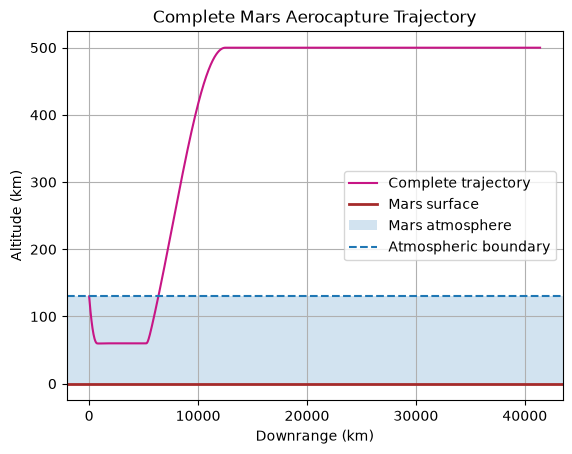

In [73]:
plt.plot(

    downrange_total/1000,

    altitude_total/1000,

    linewidth=1.5,

    label="Complete trajectory",

    color="mediumvioletred"
)

plt.axhline(

    0,

    color="brown",

    linewidth=2,

    label="Mars surface"

)

plt.axhspan(

    0,

    130,

    alpha=0.2,

    label="Mars atmosphere"

)

plt.axhline(

    130,

    linestyle="--",

    label="Atmospheric boundary"

)

plt.xlabel("Downrange (km)")
plt.ylabel("Altitude (km)")
plt.title("Complete Mars Aerocapture Trajectory")

plt.grid()
plt.legend()
plt.show()

**Velocity vs Time**

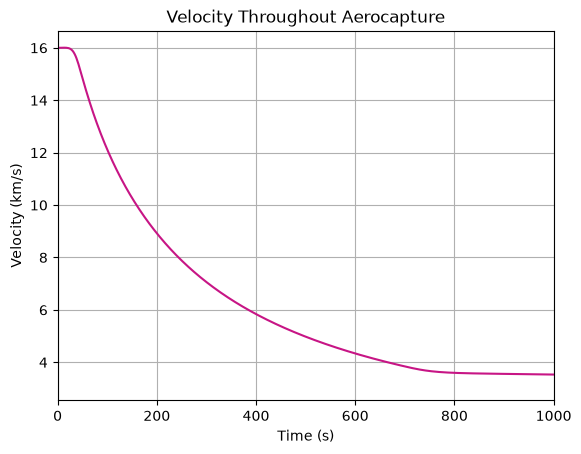

In [76]:
plt.plot(

    time_total,

    velocity_total/1000,

    linewidth=1.5,

    color="mediumvioletred"

)

plt.xlabel("Time (s)")
plt.ylabel("Velocity (km/s)")
plt.title("Velocity Throughout Aerocapture")

plt.grid()
plt.xlim(0, 1000)
plt.show()

**Altitude vs Time**

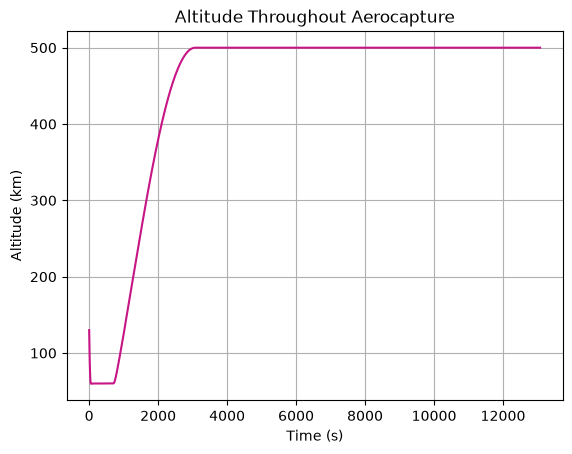

In [77]:
plt.plot(

    time_total,

    altitude_total/1000,

    linewidth=1.5,

    color="mediumvioletred"

)


plt.xlabel( "Time (s)")
plt.ylabel("Altitude (km)")
plt.title("Altitude Throughout Aerocapture")

plt.grid()
plt.show()

**Bank Angle vs Time**

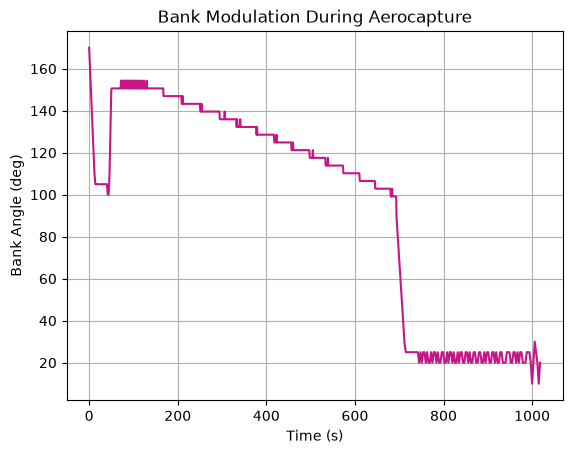

In [79]:
plt.plot(

    trajectory_time_history,

    trajectory_bank_history,

    linewidth=1.5,

    color="mediumvioletred"

)


plt.xlabel("Time (s)")
plt.ylabel("Bank Angle (deg)")
plt.title("Bank Modulation During Aerocapture")


plt.grid()
plt.show()

**Flight Path Angle vs Time**

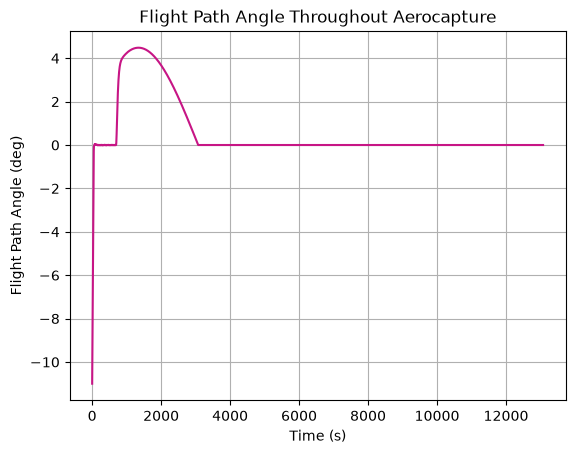

In [80]:
plt.plot(

    time_total,

    np.degrees(gamma_total),

    linewidth=1.5,

    color="mediumvioletred"

)


plt.xlabel("Time (s)")
plt.ylabel("Flight Path Angle (deg)")
plt.title("Flight Path Angle Throughout Aerocapture")


plt.grid()
plt.show()

**G-Load vs Time**

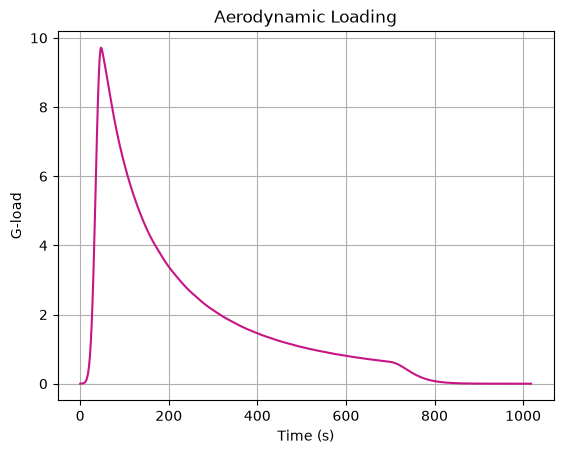

Maximum G-load = 9.717598169236647 g


In [81]:
plt.plot(
    trajectory_time_history,

    g_load_history,

    linewidth=1.5,

    color="mediumvioletred"

)


plt.xlabel("Time (s)")
plt.ylabel("G-load")
plt.title("Aerodynamic Loading")


plt.grid()
plt.show()

print("Maximum G-load =",max(g_load_history),"g")

**Heat Fluxes vs Time**

Total Heat Flux vs Time

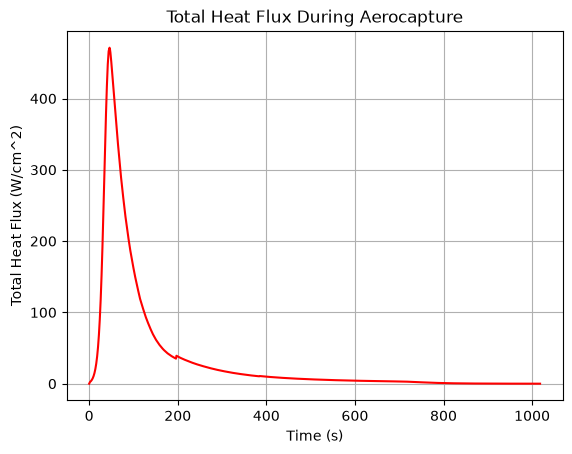

In [82]:
plt.plot(trajectory_time_history, q_total, color = "red")
plt.xlabel("Time (s)")
plt.ylabel("Total Heat Flux (W/cm^2)")
plt.title("Total Heat Flux During Aerocapture")
plt.grid()
plt.show()

Radiative and Convective Heat Flux vs Time

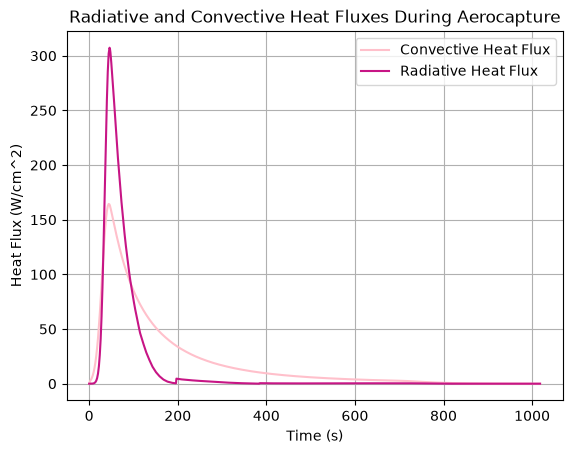

In [83]:
plt.plot(trajectory_time_history, q_c, label="Convective Heat Flux", color= "pink")
plt.plot(trajectory_time_history, q_r, label="Radiative Heat Flux", color = "mediumvioletred")
plt.xlabel("Time (s)")
plt.ylabel("Heat Flux (W/cm^2)")
plt.title("Radiative and Convective Heat Fluxes During Aerocapture")
plt.legend()
plt.grid()
plt.show()

**Mars-Centered Trajectory**

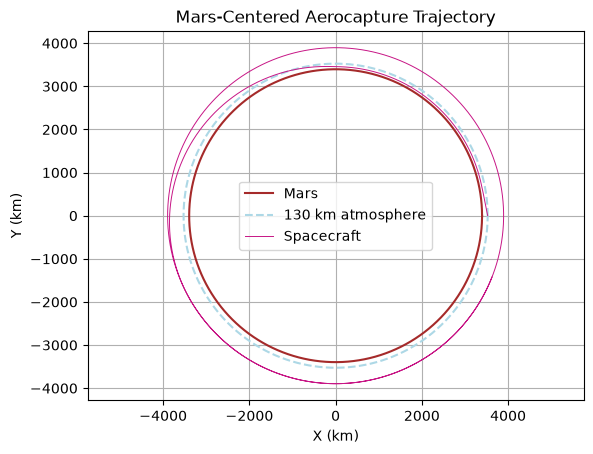

In [88]:
radius_total = (
    mars_radius
    +
    altitude_total
)

x_total = (

    radius_total
    *
    np.cos(theta_total)

)

y_total = (

    radius_total
    *
    np.sin(theta_total)

)

mars_angle = np.linspace(0, 2*np.pi, 500)

mars_x = (mars_radius* np.cos(mars_angle))
mars_y = (mars_radius*np.sin(mars_angle))


atmosphere_radius = (mars_radius+130000)

atm_x = (

    atmosphere_radius
    *
    np.cos(mars_angle)

)

atm_y = (

    atmosphere_radius
    *
    np.sin(mars_angle)

)


plt.plot(mars_x/1000, mars_y/1000, label="Mars", linewidth=1.5, color="brown")

plt.plot(atm_x/1000, atm_y/1000, linestyle="--", label="130 km atmosphere", color="lightblue")

plt.plot(x_total/1000, y_total/1000, linewidth=0.7,label="Spacecraft", color="mediumvioletred")



plt.axis("equal")
plt.xlabel("X (km)")
plt.ylabel("Y (km)")
plt.title("Mars-Centered Aerocapture Trajectory")


plt.grid()
plt.legend()
plt.show()